# Data Cleaning - VAERSVAX.csv

In [2]:
# import libraries
import pandas as pd
import numpy as np
import scipy.stats as sci
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub as kh
from kagglehub import KaggleDatasetAdapter

## Read in and inspect vax data

In [3]:
# Download latest csv version
path = kh.dataset_download("ayushggarg/covid19-vaccine-adverse-reactions")
print("Path to dataset files:", path)

Path to dataset files: /home/ekmys/.cache/kagglehub/datasets/ayushggarg/covid19-vaccine-adverse-reactions/versions/7


In [4]:
# create dataframe for df_vax
path_to_vax = path + '/VAERSVAX.csv'
df_vax = pd.read_csv(path_to_vax)
df_vax.head()

,VAERS_ID,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
0,902418,COVID19,PFIZER\BIONTECH,EH9899,1,IM,LA,COVID19 (COVID19 (PFIZER-BIONTECH))
1,902440,COVID19,PFIZER\BIONTECH,EH 9899,1,SYR,LA,COVID19 (COVID19 (PFIZER-BIONTECH))
2,902446,COVID19,PFIZER\BIONTECH,EH9899,1,IM,RA,COVID19 (COVID19 (PFIZER-BIONTECH))
3,902464,COVID19,PFIZER\BIONTECH,EH9899,UNK,IM,LA,COVID19 (COVID19 (PFIZER-BIONTECH))
4,902465,COVID19,PFIZER\BIONTECH,EH9899,1,IM,RA,COVID19 (COVID19 (PFIZER-BIONTECH))


In [5]:
# inspect shape & info for vax data
df_vax.info()
print("Shape of df_vax: " , df_vax.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1073516 entries, 0 to 1073515
Data columns (total 8 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   VAERS_ID         1073516 non-null  int64 
 1   VAX_TYPE         1073516 non-null  object
 2   VAX_MANU         1073516 non-null  object
 3   VAX_LOT          764904 non-null   object
 4   VAX_DOSE_SERIES  1068683 non-null  object
 5   VAX_ROUTE        812282 non-null   object
 6   VAX_SITE         763480 non-null   object
 7   VAX_NAME         1073516 non-null  object
dtypes: int64(1), object(7)
memory usage: 65.5+ MB
Shape of df_vax:  (1073516, 8)


In [6]:
# identify df_VAX duplicate values based on VAERS ID

# value counts of VAERS_IDs that appear more than once
duplicates = df_vax['VAERS_ID'].value_counts()[df_vax['VAERS_ID'].value_counts() > 1]
print("Number of duplicate VAERS IDs in vax dataset: ", len(duplicates))

# Count occurrences of each VAERS ID in vax dataset
ID_counts_vax = df_vax['VAERS_ID'].value_counts()
print("Count of each VAERS ID in symptoms dataset:")
print(ID_counts_vax)

Number of duplicate VAERS IDs in vax dataset:  50736
Count of each VAERS ID in symptoms dataset:
VAERS_ID
2523925    19
1215401    10
2515036     8
2636263     8
1971984     8
           ..
1337075     1
1337076     1
1337077     1
1337078     1
1337063     1
Name: count, Length: 1012894, dtype: int64


**Inspection Report**
- df_vax contains details on the vaccine administered for each adverse event, including vaccine type, manufacturer, lot, dosage series, route of administration (i.e. "intramuscular," "subcutaneous," "oral", etc.), vaccine site (i.e. left arm, right arm, etc.), and vaccine brand name (User Guide, pp. 12-16).
- Shape: df_vax contains 8 columns and 1,073,516 rows
- The following columns have missing data: VAX_LOT, VAX_SERIES, VAX_ROUTE, and VAX_SITE).
- NOTE - There are 50736 duplicate VAERS IDs in the vax dataset. This may indicate vaccines with multiple doses (e.g. the Pfizer and Moderna COVID-19 vaccines, which have 2 shots to complete the vaccine course). Will need to resolve this in data cleaning.

## Remove Whitespace

In [7]:
# remove whitespace at head & tail of string-type columns
for column in df_vax.columns:
    if df_vax[column].dtype == 'str':
        df_vax[column] = df_vax[column].str.strip()

# remove whitespace from any single-word columns
single_word_cols_vax = list(df_vax[['VAX_TYPE','VAX_MANU','VAX_LOT','VAX_DOSE_SERIES','VAX_ROUTE','VAX_SITE']])
for col in single_word_cols_vax:
    if df_vax[col].dtype == 'str':
        df_vax[col] = df_vax[col].str.replace(" ","")

# Ensure numeric columns contain only Int64 or Float type

In [8]:
# df_vax
for column in df_vax.columns:
    if df_vax[column].dtype == 'Int64':
        df_vax[column] = pd.to_numeric(df_vax[column], errors='coerce')

for column in df_vax.columns:
    if df_vax[column].dtype == 'Float':
        df_vax[column] = pd.to_numeric(df_vax[column], errors = 'coerce')

'''Note - Setting errors = 'coerce' in loops above to ensure non-numeric values are listed as NaN rather than raising an exception'''

"Note - Setting errors = 'coerce' in loops above to ensure non-numeric values are listed as NaN rather than raising an exception"

## Ensure categorical data contains valid entries

In [9]:
# get unique values for relevant columns
unique_VAX_TYPE = list(df_vax['VAX_TYPE'].unique())
unique_manufacturer = list(df_vax['VAX_MANU'].unique())
unique_dose_series = list(df_vax['VAX_DOSE_SERIES'].unique())
unique_vax_site = list(df_vax['VAX_SITE'].unique())
unique_vax_route = list(df_vax['VAX_ROUTE'].unique())

In [10]:
print("Unique values in 'VAX_TYPE': ", unique_VAX_TYPE)
print("Unique values in 'VAX_MANU': ", unique_manufacturer)
print("Unique values in 'VAX_DOSE_SERIES': ", unique_dose_series)
print("Unique values in 'VAX_ROUTE': ", unique_vax_route)
print("Unique values in 'VAX_SITE': ", unique_vax_site)

Unique values in 'VAX_TYPE':  ['COVID19', 'COVID19-2']
Unique values in 'VAX_MANU':  ['PFIZER\\BIONTECH', 'UNKNOWN MANUFACTURER', 'MODERNA', 'JANSSEN', 'NOVAVAX']
Unique values in 'VAX_DOSE_SERIES':  ['1', 'UNK', nan, '2', '7+', '4', '5', '6', '3']
Unique values in 'VAX_ROUTE':  ['IM', 'SYR', nan, 'OT', 'SC', 'UN', 'ID', 'JET', 'IN', 'PO']
Unique values in 'VAX_SITE':  ['LA', 'RA', nan, 'AR', 'UN', 'OT', 'LL', 'RL', 'GM', 'LG', 'NS', 'MO']


**df_VAX Labeled Data Issues:**

- VAX_TYPE - no issues

- VAX_MANU - no issues; will remove 'UNKNOWN MANUFACTURER', 'JANSSEN' and 'NOVAVAX' for Pfizer and Moderna only stakeholders

- VAX_DOSE_SERIES - Seems like this should either be just an integer or 'UNK' for 'Unknown' - double-check '7+' to see if it's a typo. Note - "The VAERS 1 field VAX_DOSE was discontinued in the VAERS 2 form; when a value exists, a 1 is added to equate to the VAX_DOSE_SERIES field" (User Guide, p. 16).

- VAX_ROUTE - no issues; all entries align with User Guide abbreviations (User Guide, p. 16). Will fill in nan values with 'UN' for Unknown.

- VAX_SITE - no controlled list of abbreviations in User Guide; will assume these align with standard abbreviations for now. Will fill in nan values with UN for 'Unknown.'

### VAX_DOSE_SERIES

In [11]:
# count instances of vaccine dosage
print("1 dose", (df_vax['VAX_DOSE_SERIES'] == '1').sum())
print("2 doses", (df_vax['VAX_DOSE_SERIES'] == '2').sum())
print("3 doses", (df_vax['VAX_DOSE_SERIES'] == '3').sum())
print("4 doses", (df_vax['VAX_DOSE_SERIES'] == '4').sum())
print("5 doses", (df_vax['VAX_DOSE_SERIES'] == '5').sum())
print("6 doses", (df_vax['VAX_DOSE_SERIES'] == '6').sum())
print("7+ doses", (df_vax['VAX_DOSE_SERIES'] == '7+').sum())
print("dose # unknown", (df_vax['VAX_DOSE_SERIES'] == 'UNK').sum())

1 dose 449414
2 doses 285127
3 doses 106661
4 doses 38497
5 doses 15734
6 doses 2087
7+ doses 670
dose # unknown 170493


In [12]:
# change +7 to just 7
df_vax['VAX_DOSE_SERIES'] = df_vax['VAX_DOSE_SERIES'].replace("7+", "7")

In [13]:
print("7+ doses", (df_vax['VAX_DOSE_SERIES'] == "7").sum())

7+ doses 670


In [14]:
## check proportion of unknown values
(len(df_vax[df_vax['VAX_DOSE_SERIES'] == 'UNK'])/len(df_vax))*100

# Unknown values are about 16% of the VAX_DOSE_SERIES

15.881738138975107

In [15]:
# convert 'UNK' values to NULL
df_vax['VAX_DOSE_SERIES'] = df_vax['VAX_DOSE_SERIES'].replace("UNK", np.nan)

# convert data type to Int64
df_vax['VAX_DOSE_SERIES'] = df_vax['VAX_DOSE_SERIES'].astype('Int64')

In [16]:
# Verify transformation - code from Brian Zavala's EDA
print(df_vax['VAX_DOSE_SERIES'].value_counts())
print(f"Null values: {df_vax['VAX_DOSE_SERIES'].isnull().sum()}")

VAX_DOSE_SERIES
1    449414
2    285127
3    106661
4     38497
5     15734
6      2087
7       670
Name: count, dtype: Int64
Null values: 175326


### VAX_LOT (investigate unique values & remove remaining whitespace)

In [17]:
# investigate unique VAX_LOT values
display(df_vax)

,VAERS_ID,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
0,902418,COVID19,PFIZER\BIONTECH,EH9899,1,IM,LA,COVID19 (COVID19 (PFIZER-BIONTECH))
1,902440,COVID19,PFIZER\BIONTECH,EH 9899,1,SYR,LA,COVID19 (COVID19 (PFIZER-BIONTECH))
2,902446,COVID19,PFIZER\BIONTECH,EH9899,1,IM,RA,COVID19 (COVID19 (PFIZER-BIONTECH))
3,902464,COVID19,PFIZER\BIONTECH,EH9899,<NA>,IM,LA,COVID19 (COVID19 (PFIZER-BIONTECH))
4,902465,COVID19,PFIZER\BIONTECH,EH9899,1,IM,RA,COVID19 (COVID19 (PFIZER-BIONTECH))
...,...,...,...,...,...,...,...,...
1073511,2776307,COVID19,PFIZER\BIONTECH,NaN,1,NaN,LA,COVID19 (COVID19 (PFIZER-BIONTECH))
1073512,2776309,COVID19,PFIZER\BIONTECH,NaN,1,NaN,NaN,COVID19 (COVID19 (PFIZER-BIONTECH))
1073513,2776310,COVID19,PFIZER\BIONTECH,NaN,1,NaN,LA,COVID19 (COVID19 (PFIZER-BIONTECH))
1073514,2776312,COVID19,PFIZER\BIONTECH,HM7010,1,NaN,NaN,COVID19 (COVID19 (PFIZER-BIONTECH))


In [18]:
print(len(df_vax[df_vax['VAX_LOT'] == 'EH 9899']))
print(df_vax[df_vax['VAX_LOT'] == 'EH 9899'][0:10])

81
      VAERS_ID VAX_TYPE         VAX_MANU  VAX_LOT  VAX_DOSE_SERIES VAX_ROUTE  \
1       902440  COVID19  PFIZER\BIONTECH  EH 9899                1       SYR   
151     903023  COVID19  PFIZER\BIONTECH  EH 9899                1        IM   
182     903122  COVID19  PFIZER\BIONTECH  EH 9899                1        IM   
186     903128  COVID19  PFIZER\BIONTECH  EH 9899                1        IM   
459     903537  COVID19  PFIZER\BIONTECH  EH 9899                1       SYR   
807     903985  COVID19  PFIZER\BIONTECH  EH 9899                1       SYR   
853     904040  COVID19  PFIZER\BIONTECH  EH 9899                1        IM   
1030    904267  COVID19  PFIZER\BIONTECH  EH 9899                1        IM   
1075    904322  COVID19  PFIZER\BIONTECH  EH 9899                1        IM   
1335    904702  COVID19  PFIZER\BIONTECH  EH 9899                1        IM   

     VAX_SITE                             VAX_NAME  
1          LA  COVID19 (COVID19 (PFIZER-BIONTECH))  
151       

In [19]:
# strip remaining whitespace from 'VAX_LOT' (if any)
df_vax['VAX_LOT'] = df_vax['VAX_LOT'].str.strip()
df_vax['VAX_LOT'] = df_vax['VAX_LOT'].str.replace(" ", "")

In [20]:
df_vax['VAX_LOT'][0:10]

0    EH9899
1    EH9899
2    EH9899
3    EH9899
4    EH9899
5    EH9899
6       NaN
7    EH9899
8    EH9899
9    EH9899
Name: VAX_LOT, dtype: object

In [21]:
# convert strings to uppercase
df_vax['VAX_LOT'] = df_vax['VAX_LOT'].str.upper()

In [22]:
# get unique values in VAX_LOT
vax_lot_unique = df_vax['VAX_LOT'].unique().tolist()
print(len(vax_lot_unique))
print(vax_lot_unique[0:10])

36077
['EH9899', nan, 'GH9899', 'EK5730', 'EJ1685', 'EJ685', 'EZ5730', 'PH9899', 'PAA156057', 'EH9989']


### VAX_ROUTE, VAX_SITE

In [23]:
# replace NULL values with UN for 'Unknown'
df_vax['VAX_ROUTE'] = df_vax['VAX_ROUTE'].replace(np.nan, 'UN')
df_vax['VAX_SITE'] = df_vax['VAX_SITE'].replace(np.nan, 'UN')

In [24]:
# verify replacement
print(len(df_vax[df_vax['VAX_ROUTE'] == 'UN']))
print(len(df_vax[df_vax['VAX_SITE'] == 'UN']))
print(len(df_vax[df_vax['VAX_ROUTE'].isna()]))
print(len(df_vax[df_vax['VAX_SITE'].isna()]))

269298
336939
0
0


## Identify & Drop Duplicate Rows

In [25]:
# identify wholesale duplicates (where the entire row is the same)
duplicates_vax_df = df_vax[df_vax.duplicated()].sort_values('VAERS_ID')
display(duplicates_vax_df)

# test to ensure this got duplicates correctly
test_duplicates = df_vax[df_vax['VAERS_ID'] == 907159]
test_duplicates

,VAERS_ID,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
2722,907159,COVID19,PFIZER\BIONTECH,EH9899,1,SYR,LA,COVID19 (COVID19 (PFIZER-BIONTECH))
2835,907330,COVID19,MODERNA,011J20A,1,SYR,LA,COVID19 (COVID19 (MODERNA))
5772,911085,COVID19,PFIZER\BIONTECH,EH9899,1,IM,UN,COVID19 (COVID19 (PFIZER-BIONTECH))
6839,912442,COVID19,PFIZER\BIONTECH,NaN,<NA>,UN,UN,COVID19 (COVID19 (PFIZER-BIONTECH))
8042,913869,COVID19,PFIZER\BIONTECH,EK9231,1,IM,LA,COVID19 (COVID19 (PFIZER-BIONTECH))
...,...,...,...,...,...,...,...,...
1070973,2763732,COVID19,PFIZER\BIONTECH,NaN,1,UN,UN,COVID19 (COVID19 (PFIZER-BIONTECH))
1070974,2763732,COVID19,PFIZER\BIONTECH,NaN,1,UN,UN,COVID19 (COVID19 (PFIZER-BIONTECH))
1072366,2771190,COVID19,JANSSEN,206A21A,<NA>,UN,UN,COVID19 (COVID19 (JANSSEN))
1073368,2775527,COVID19,PFIZER\BIONTECH,NaN,<NA>,UN,UN,COVID19 (COVID19 (PFIZER-BIONTECH))


,VAERS_ID,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
2721,907159,COVID19,PFIZER\BIONTECH,EH9899,1,SYR,LA,COVID19 (COVID19 (PFIZER-BIONTECH))
2722,907159,COVID19,PFIZER\BIONTECH,EH9899,1,SYR,LA,COVID19 (COVID19 (PFIZER-BIONTECH))


In [26]:
print(len(duplicates))
print(df_vax.shape)

50736
(1073516, 8)


In [27]:
# drop wholesale duplicates
df_vax = df_vax.drop_duplicates()

In [28]:
print("New shape: ", df_vax.shape)

New shape:  (1071521, 8)


## Remove Outliers
Code for this section from Brian Zavala's EDA

In [29]:
## IRQ Functions for outliers - created these during lab_02_todo
def get_iqr_upper(x):
    return x.quantile(0.75)+(1.5*(x.quantile(0.75)-x.quantile(0.25)))

def get_iqr_lower(x):
    iqr_low = x.quantile(0.25)-(1.5*(x.quantile(0.75)-x.quantile(0.25)))
    if iqr_low < 0:
        return 0
    else:
        return iqr_low

In [30]:
## Code from Brian Zavala's EDA - CHECKING FOR & REMOVING OUTLIERS
# Getting descriptive statistics of outliers for VAX_DOSE_SERIES
print(f'{df_vax.info()}\n')
print(df_vax.describe(percentiles=[0.25,0.5,0.75]).T)
print(f'\nUpper IQR: {get_iqr_upper(df_vax['VAX_DOSE_SERIES'])}\n')

<class 'pandas.core.frame.DataFrame'>
Index: 1071521 entries, 0 to 1073515
Data columns (total 8 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   VAERS_ID         1071521 non-null  int64 
 1   VAX_TYPE         1071521 non-null  object
 2   VAX_MANU         1071521 non-null  object
 3   VAX_LOT          764011 non-null   object
 4   VAX_DOSE_SERIES  897320 non-null   Int64 
 5   VAX_ROUTE        1071521 non-null  object
 6   VAX_SITE         1071521 non-null  object
 7   VAX_NAME         1071521 non-null  object
dtypes: Int64(1), int64(1), object(6)
memory usage: 74.6+ MB
None

                     count            mean            std       min  \
VAERS_ID         1071521.0  1716753.125969  544321.897964  902418.0   
VAX_DOSE_SERIES   897320.0        1.769864       0.975264       1.0   

                       25%        50%        75%        max  
VAERS_ID         1231786.0  1641802.0  2170045.0  2776336.0  
VAX_DOSE_SERIES   

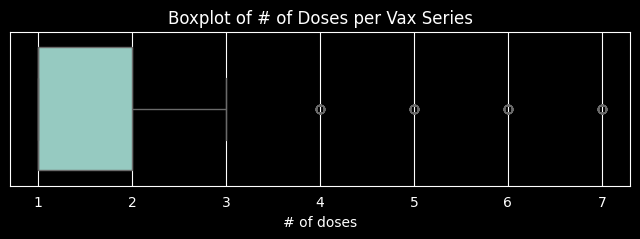

In [31]:
# Boxplot for VAX_DOSE_SERIES (visualizing outliers for VAX_DOSE_SERIES)
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_vax, x= df_vax['VAX_DOSE_SERIES'])
ax.set_xlabel('# of doses',fontsize = 10)
ax.set_title('Boxplot of # of Doses per Vax Series', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

In [32]:
# Dropping outliers - creating new DF that contains version of df_vax w/o int64 outliers. The get_iqr_upper function calculates upper bound of column and removes observations from outside that upper bound.
df_vax_noliers = df_vax[df_vax['VAX_DOSE_SERIES']<(get_iqr_upper(df_vax['VAX_DOSE_SERIES']))]
print(f'\n{df_vax_noliers.info()}\n')
# NOTE: I am removing outliers from these as it seems bizarre to have COVID19 dose requirements in the 4-7 range. I could see it being possible, but again, it looks to fall outside the range of the typical.

<class 'pandas.core.frame.DataFrame'>
Index: 840368 entries, 0 to 1073514
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   VAERS_ID         840368 non-null  int64 
 1   VAX_TYPE         840368 non-null  object
 2   VAX_MANU         840368 non-null  object
 3   VAX_LOT          629352 non-null  object
 4   VAX_DOSE_SERIES  840368 non-null  Int64 
 5   VAX_ROUTE        840368 non-null  object
 6   VAX_SITE         840368 non-null  object
 7   VAX_NAME         840368 non-null  object
dtypes: Int64(1), int64(1), object(6)
memory usage: 58.5+ MB

None



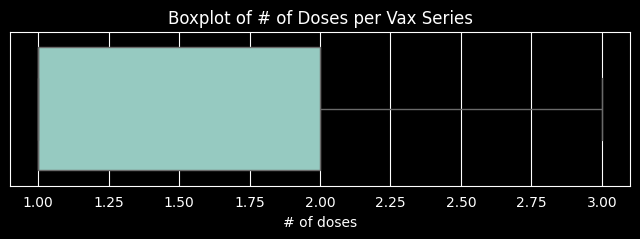

In [33]:
# Boxplot for VAX_DOSE_SERIES (visualizing VAX_DOSE_SERIES w/o outliers)
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_vax_noliers, x= df_vax_noliers['VAX_DOSE_SERIES'])
ax.set_xlabel('# of doses',fontsize = 10)
ax.set_title('Boxplot of # of Doses per Vax Series', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

## VAX_NAME - simplify names

In [34]:
# get unique values from VAX_NAME (just in case)
unique_VAX_NAME = df_vax['VAX_NAME'].unique()
unique_VAX_NAME

array(['COVID19 (COVID19 (PFIZER-BIONTECH))',
       'COVID19 (COVID19 (UNKNOWN))', 'COVID19 (COVID19 (MODERNA))',
       'COVID19 (COVID19 (JANSSEN))',
       'COVID19 (COVID19 (MODERNA BIVALENT))',
       'COVID19 (COVID19 (PFIZER-BIONTECH BIVALENT))',
       'COVID19 (COVID19 (NOVAVAX))'], dtype=object)

In [35]:
# simplify vax names
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (PFIZER-BIONTECH))', 'PFIZER-BIONTECH')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (UNKNOWN))','Unknown')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (MODERNA))','MODERNA')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (JANSSEN))','JANSSEN')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (MODERNA BIVALENT))','MODERNA BIVALENT')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (PFIZER-BIONTECH BIVALENT))','PFIZER-BIONTECH BIVALENT')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (NOVAVAX))','NOVAVAX')

In [36]:
# get unique values from VAX_NAME again
unique_VAX_NAME = df_vax['VAX_NAME'].unique()
unique_VAX_NAME

array(['PFIZER-BIONTECH', 'Unknown', 'MODERNA', 'JANSSEN',
       'MODERNA BIVALENT', 'PFIZER-BIONTECH BIVALENT', 'NOVAVAX'],
      dtype=object)

# Save cleaned vax data to csv

In [37]:
# save transformed symptoms dataframe to csv
path_to_save = path + '/VAERSVAX_cleaned.csv'
path_to_save

# save transformed symptoms dataframe to csv
df_vax.to_csv(path_to_save)